# Machine Learning Assignment 2 - Unsupervised Learning Assignment - Clustering Analysis for Cardiac Health Assessment

Suppressing all FutureWarnings to enhance code readibility

https://saturncloud.io/blog/how-to-suppress-pandas-future-warning-a-guide-for-data-scientists/#:~:text=Method%201%3A%20Using%20the%20Warnings%20Module&text=In%20this%20example%2C%20we%20import,FutureWarning%20messages%20generated%20by%20Pandas.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. Understanding the Dataset (1 Mark)

- Explore the dataset and understand its features.- 
Explain why clustering is an appropriate unsupervised learning technique for this problem, particularly in assessing cardiac health risks.
- Identify which features are likely to have more influence on cluster formation, such as age, ejection fraction, and the presence of diabetes.


The following link was used to help with exploring and understanding the data:
https://datacarpentry.org/python-ecology-lesson/02-starting-with-data.html

In [2]:
import pandas as pd
from IPython.display import display

In [3]:
df_original = pd.read_csv("C:/Users/Admin/Desktop/MSc/Modified_Heart_failure_data.csv")
df = df_original

In [4]:
# Inspect the first few rows of the data
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,patient_id
0,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.9,130.0,1.0,0.0,4.0,0
1,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.1,136.0,1.0,0.0,6.0,1
2,65.0,NaN,146.0,0.0,20.0,0.0,162000.00,1.3,129.0,1.0,NaN,7.0,2
3,50.0,1.0,111.0,0.0,20.0,0.0,210000.00,NaN,137.0,1.0,0.0,7.0,3
4,65.0,1.0,160.0,1.0,20.0,0.0,327000.00,2.7,116.0,0.0,0.0,8.0,4


In [5]:
# Check to see what Data Structure we are provided with
type(df)

pandas.core.frame.DataFrame

In [6]:
# Assess what Data Types each column has
datatypes = df.dtypes
display(pd.DataFrame(datatypes).T)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,patient_id
0,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


In [7]:
# label the variables as either continuous or categorical
continuous_variables =['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium']
categorical_variables =['anaemia','diabetes','high_blood_pressure','sex','smoking']

In [8]:
# create a function to apply the describe method to get a description of the continuous variables in the data frame for all variables specified in a given list
def describe_variables(dataframe, variable_list):
    for v in variable_list:
        if v in dataframe.columns:
            description = dataframe[v].describe()
            display(description.to_frame().T)
        else:
            print(f"Warning: {v} is not a column in the DataFrame")

The display function was used to more easily view the distribution of each variable. The following link helped in understanding how to use the display function:

https://www.geeksforgeeks.org/display-the-pandas-dataframe-in-table-style/

In [9]:
# apply describe to all continuous variables in df
describe_variables(df, continuous_variables)

,count,mean,std,min,25%,50%,75%,max
age,270.0,60.93457,11.838766,40.0,52.0,60.0,70.0,95.0


,count,mean,std,min,25%,50%,75%,max
creatinine_phosphokinase,270.0,574.266667,958.53276,23.0,119.5,250.0,582.0,7861.0


,count,mean,std,min,25%,50%,75%,max
ejection_fraction,270.0,37.622222,11.715885,14.0,30.0,38.0,45.0,70.0


,count,mean,std,min,25%,50%,75%,max
platelets,270.0,261522.410185,97633.259068,25100.0,210250.0,261000.0,302000.0,850000.0


,count,mean,std,min,25%,50%,75%,max
serum_creatinine,270.0,1.355519,0.981258,0.5,0.9,1.1,1.4,9.4


,count,mean,std,min,25%,50%,75%,max
serum_sodium,270.0,136.722222,4.226033,113.0,134.0,137.0,139.0,148.0


In [10]:
# create a function to apply value_counts function to get distrubtion for all variables specified in a given list for the given dataframe
def value_counts_variables(dataframe, variable_list):
    for v in variable_list:
        if v in dataframe.columns:
            description = dataframe[v].value_counts(normalize=True)*100
            description = description.round(1).astype(str) + '%'
            display(description.to_frame().T)            
        else:
            print(f"Warning: {v} is not a column in the DataFrame")

In [11]:
# apply value_counts to all categorical variables in df
value_counts_variables(df, categorical_variables)

anaemia,0.0,1.0
proportion,56.3%,43.7%


diabetes,0.0,1.0
proportion,58.9%,41.1%


high_blood_pressure,0.0,1.0
proportion,64.4%,35.6%


sex,1.0,0.0
proportion,64.1%,35.9%


smoking,0.0,1.0
proportion,70.0%,30.0%


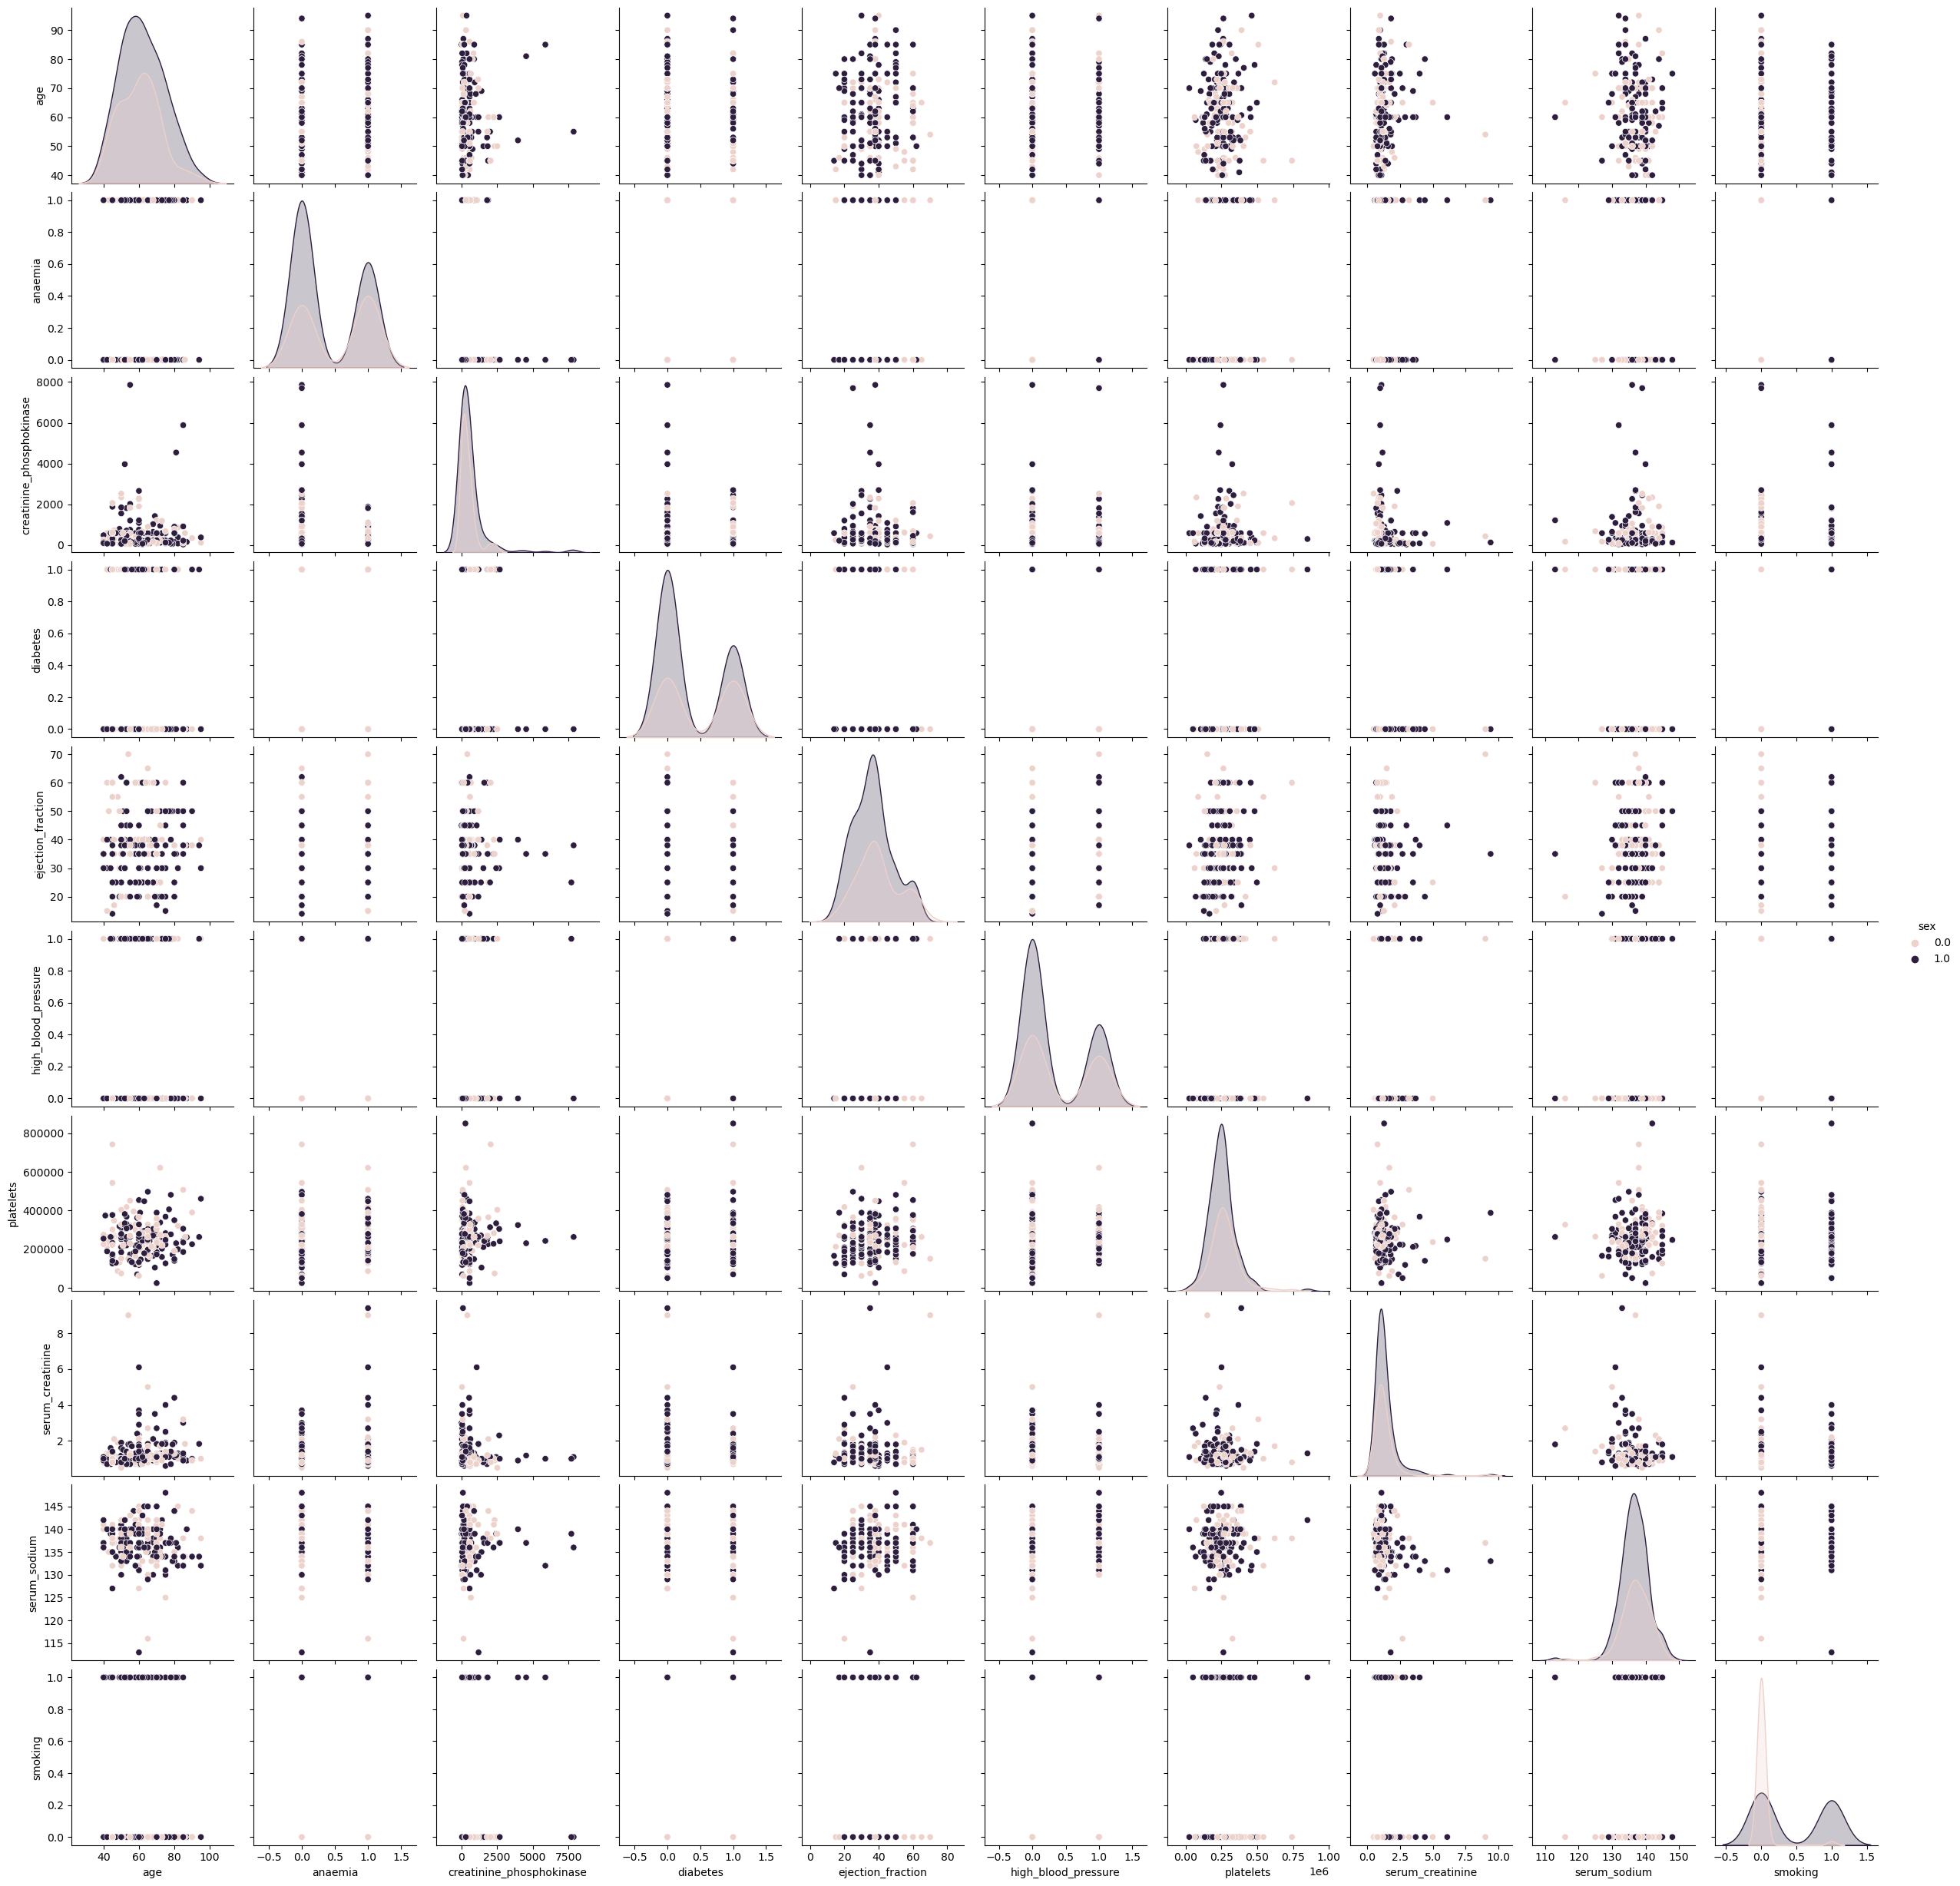

In [17]:
# Create Pair Plots
import seaborn
import matplotlib.pyplot as plt

df_view = df.drop(columns=['time','patient_id'],errors='ignore')
seaborn.pairplot(df_view,hue ='sex')

# Display the plot
plt.show()

The link below was used to understand how to use pairplot from Seaborn

https://www.geeksforgeeks.org/python-seaborn-pairplot-method/

- The above pariwise plots provide us with a good understanding of the distribtions for continous variables
- We also see some potential patterns emerge, for example, some variables display clusters when plotted with other variables (e.g., creatinine_phosphokinase, platelets, serum_creatinine, serum_sodium)
- This indicates that these variables are likely to have more influence on cluster formation

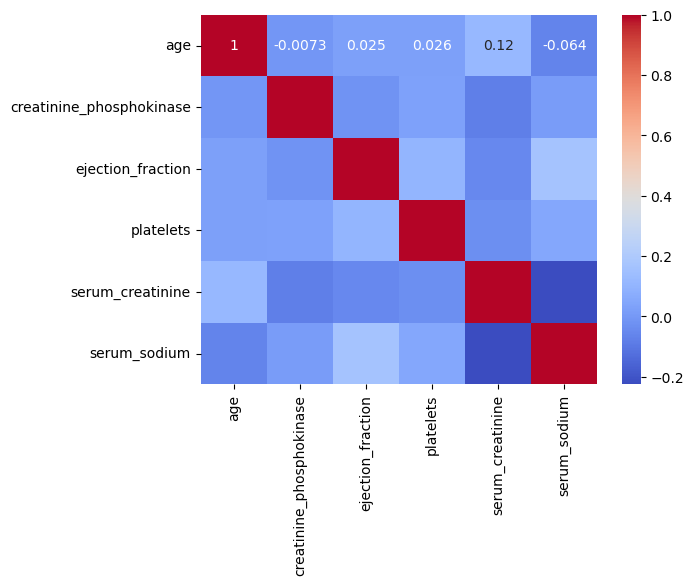

In [23]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

correlation_matrix = df[continuous_variables].corr()

# Create a heatmap to visualize the correlation matrix
# sn.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
sn.heatmap(correlation_matrix,annot = True, cmap = "coolwarm")

# Display the plot
plt.show()

The following links were used to help build the heatmap:

https://www.geeksforgeeks.org/seaborn-heatmap-a-comprehensive-guide/

https://seaborn.pydata.org/tutorial/color_palettes.html

Based on the above graph, there are no contiuous variables highly correlated with one another

### 2. Data Pre-Processing (1 Mark)

- Handle missing values, feature scaling, and any other necessary transformations to prepare the dataset for clustering.
- 
Provide justification for the transformations and explain their importance, particularly in maintaining data integrity and ensuring accurate cluster formation.

Checking for missing values in each variable

https://miamioh.edu/centers-institutes/center-for-analytics-data-science/students/coding-tutorials/python/data-cleaning.html#:~:text=Next%2C%20we%20would%20like%20to,False%20for%20non%2Dmissing%20cells.

In [24]:
df = df.drop(columns=['time','patient_id'],errors='ignore')
# removing time and patient_id from the dataset as they appear to be indicators of the time at which the measurements were taken and a patient identifier
# so, not useful for clustering

df.isnull().sum()

age                         29
anaemia                     29
creatinine_phosphokinase    29
diabetes                    29
ejection_fraction           29
high_blood_pressure         29
platelets                   29
serum_creatinine            29
serum_sodium                29
sex                         29
smoking                     29
dtype: int64

- From the above we can see that there are missing values in the data, with 29 rows in each column (other than patient_id) with missing values.

- However, we can see from section 1 df.head() function that they are not the same 29 records (if they were, we might consider removing all 29 but this is not the case).

**Continuous Variables**:

For continuous variables (e.g., age, creatinine_phosphokinase) assign the mean value to missing entries

The following link was viewed to help understand how to replace missing values with the mean:

https://www.geeksforgeeks.org/replacing-missing-values-using-pandas-in-python/

I then built a function which will do this for a list of variables

In [26]:
# create a function to assign the mean value to missing entries for all variables specified in a given list
def replace_missing_values_mean(dataframe, variable_list):
    for v in variable_list:
        if v in dataframe.columns:
            dataframe[v].fillna(dataframe[v].mean(), inplace=True)
        else:
            print(f"Warning: {v} is not a column in the DataFrame")

In [27]:
replace_missing_values_mean(df, continuous_variables)

In [28]:
# Check that it has worked
df.isnull().sum()

age                          0
anaemia                     29
creatinine_phosphokinase     0
diabetes                    29
ejection_fraction            0
high_blood_pressure         29
platelets                    0
serum_creatinine             0
serum_sodium                 0
sex                         29
smoking                     29
dtype: int64

**Categorical Variables**:

For categorical variables (e.g., anaemia, sex, smoker) assign values based on the distribution to ensure that the distribution is unchanged 

The value_counts function was used again to get the distribution of categorical variables. 
The link below was used to understand how numpy.random.choice() can be used to get random samples of the distribution. 
The missing values were then replaced with the random samples.

https://www.geeksforgeeks.org/numpy-random-choice-in-python/

This was then put into a fuction so that it could be applied across all categorical variables

In [31]:
import numpy as np

# Create a function to assign values to missing values for categorical variables based on their distribution
def replace_missing_values_distribution(dataframe, variable_list):
    for v in variable_list:
        if v in dataframe.columns:
            value_counts = dataframe[v].value_counts(normalize=True)  # Calculate the distribution of existing values, as per code in section 1 above
            missing_indices = dataframe[dataframe[v].isna()].index  # Get the indices of missing values in the specific column
            random_values = np.random.choice(value_counts.index, size=len(missing_indices), p=value_counts.values)  # Generate random values based on the distribution
            dataframe.loc[missing_indices, v] = random_values  # Fill the missing values with the generated random values
        else:
            print(f"Warning: {v} is not a column in the DataFrame")

In [32]:
# Replace missing values 
replace_missing_values_distribution(df, categorical_variables)

In [33]:
# Check that it has worked
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
dtype: int64

Now check the distributions again to see if they look ok, comparing to the original distributions in part 1- we expect that they will not have changed

In [34]:
import pandas as pd

means_df_original = df_original.mean()
means_df = df.mean()

stdev_df_original = df_original.std()
stdev_df = df.std()

comparison_df = pd.DataFrame({
    'Original_dataset_means': means_df_original,
    'Formatted_dataset_means': means_df,
    'Diff in means': means_df_original - means_df,
    'Original_dataset_stdev': stdev_df_original,
    'Formatted_dataset_stdev': stdev_df,
    'Diff in stdev': stdev_df_original - stdev_df
})

print(comparison_df)

                          Original_dataset_means  Formatted_dataset_means  \
age                                    60.934570                60.934570   
anaemia                                 0.437037                 0.431438   
creatinine_phosphokinase              574.266667               574.266667   
diabetes                                0.411111                 0.404682   
ejection_fraction                      37.622222                37.622222   
high_blood_pressure                     0.355556                 0.367893   
patient_id                            149.000000                      NaN   
platelets                          261522.410185            261522.410185   
serum_creatinine                        1.355519                 1.355519   
serum_sodium                          136.722222               136.722222   
sex                                     0.640741                 0.632107   
smoking                                 0.300000                 0.317726   

In [35]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.900000,130.0,1.0,0.0
1,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.100000,136.0,1.0,0.0
2,65.0,0.0,146.0,0.0,20.0,0.0,162000.00,1.300000,129.0,1.0,0.0
3,50.0,1.0,111.0,0.0,20.0,0.0,210000.00,1.355519,137.0,1.0,0.0
4,65.0,1.0,160.0,1.0,20.0,0.0,327000.00,2.700000,116.0,0.0,0.0


**Feature Scaling**:

We need to apply feature scaling to the independent continuous variables to mitigate bias when fitting models. Scaling prevents features from dominating the ML process due to the magnitude of their values.

https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e

Choice of scaler: 

StandardScaler was used for the continuous variables since it works well when variables are normally distributed, like we have with some of our continuous variables (e.g. age). MinMaxScaler was also considered, which brings all the variables to a range [0,1], making it consistent with the categorical variables. However, this was not considered necessary since we don't expect the clustering algorithms we will be using to be sensitive to the type of scale we use (unlike Neural Networks for example).


https://www.atoti.io/articles/when-to-perform-a-feature-scaling/

In [36]:
from sklearn.preprocessing import StandardScaler 

In [37]:
scaler = StandardScaler()
df[continuous_variables] = scaler.fit_transform(df[continuous_variables])

In [38]:
df_scaled = pd.concat([df[continuous_variables], df[categorical_variables]], axis=1)

In [39]:
df_scaled.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
0,1.252582,0.008506,-1.585788,0.037553,0.585004,-1.677025,0.0,0.0,1.0,1.0,0.0
1,-0.528497,8.014665,0.033995,0.019822,-0.274535,-0.180176,0.0,0.0,0.0,1.0,0.0
2,0.362042,-0.471050,-1.585788,-1.074688,-0.059650,-1.926499,0.0,0.0,0.0,1.0,0.0
3,-0.973766,-0.509546,-1.585788,-0.556362,0.000000,0.069299,1.0,0.0,0.0,1.0,0.0
4,0.362042,-0.455651,-1.585788,0.707057,1.444544,-5.169671,1.0,1.0,0.0,0.0,0.0


### 3. Applying Clustering Algorithms (5 Marks)

- Apply two different clustering algorithms (e.g., K-Means and Hierarchical Clustering) to the dataset.- 
Describe how each algorithm works and compare their suitability for this dataset
- Visualize the clusters using methods such as specifically 2D plots
- Visualize the clusters using methods such as cluster heatmaps with techniques like PCA for dimensionality reduction if necessary.ry.

**(1) K-Means**

The following link was used to help write code for the K-Means clustering algorithm:

https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/

Importing the required libraries

In [42]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

Building the Clustering Model and Calculating Distortion and Inertia

In [43]:
# Initialize lists to store distortion and inertia values
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

# Fit K-means for different values of k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(df_scaled)
    
    # Calculate distortion as the average squared distance from points to their cluster centers
    distortions.append(sum(np.min(cdist(df_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / df_scaled.shape[0])
    
    # Inertia is calculated directly by KMeans
    inertias.append(kmeanModel.inertia_)
    
    # Store the mappings for easy access
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

Tabulating and Visualizing the Results

Distortion values:
1 : 7.168085368172615
2 : 6.35570241086658
3 : 5.726327380584731
4 : 5.208163377342551
5 : 4.7325126017796
6 : 4.360479372727914
7 : 4.0701837542340344
8 : 3.838281668529664
9 : 3.636471886948598


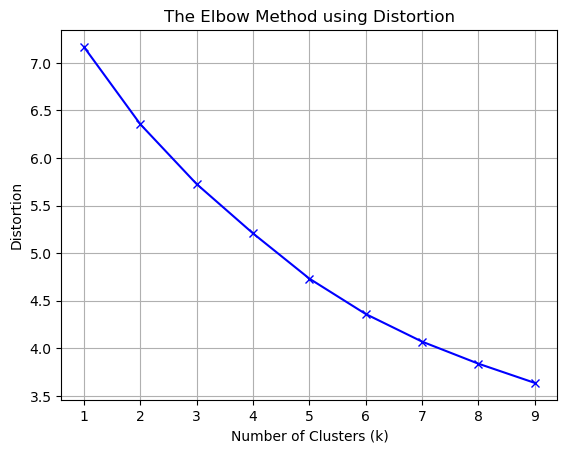

In [44]:
# Displaying Distortion Values
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')
# Plotting the graph of k versus Distortion
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.grid()
plt.show()

Inertia values:
1 : 2143.2575250836117
2 : 1900.3550208491072
3 : 1712.171886794835
4 : 1557.2408498254222
5 : 1415.021267932101
6 : 1303.7833324456458
7 : 1216.984942515976
8 : 1147.6462188903693
9 : 1087.3050941976314


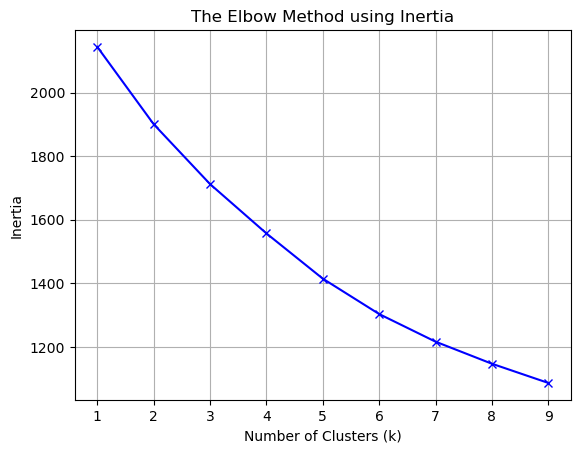

In [45]:
# Displaying Inertia Values:
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')
# Plotting the graph of k versus Inertia
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.grid()
plt.show()

We can see from the above that the Elbow Method does not help us select an optimal number of clusters (k).

The Silhouette Score is therefore used to help us.

https://www.analyticsvidhya.com/blog/2021/05/k-mean-getting-the-optimal-number-of-clusters/

https://dzone.com/articles/kmeans-silhouette-score-explained-with-python-exam

In [46]:
from sklearn.metrics import silhouette_score

C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

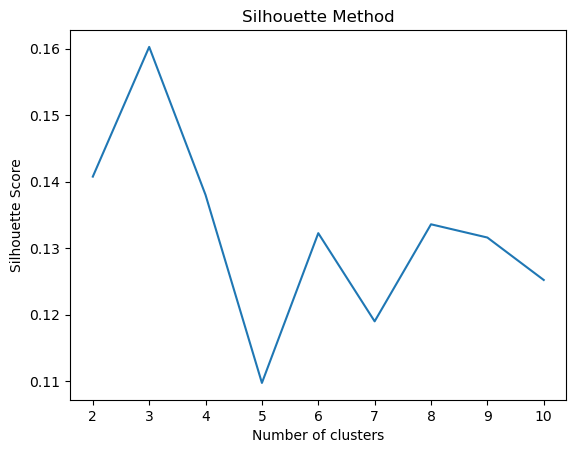

In [47]:
# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

k = 3 provides the best Silhouette score so we will select this as the number of clusters. Let's fit the model again with our chosen value of clusters, keeping the same random seed as per above 

In [52]:
# Fit the K-Means model with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

C:\Users\Admin\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [53]:
# Evaluate the clustering
silhouette_avg = silhouette_score(df_scaled.drop('cluster', axis=1), df_scaled['cluster'])
print(silhouette_avg)

0.15798147362597978


Since we have many dimensions, I use Principal Components Analysis (PCA) to reduce the data into 2 dimensions to make it easier to visualize the clusters. The following links were used to help:

https://www.geeksforgeeks.org/reduce-data-dimentionality-using-pca-python/

https://stackoverflow.com/questions/23838056/what-is-the-difference-between-transform-and-fit-transform-in-sklearn

In [54]:
# Reduce the data to 2 dimensions for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled.drop('cluster', axis=1))

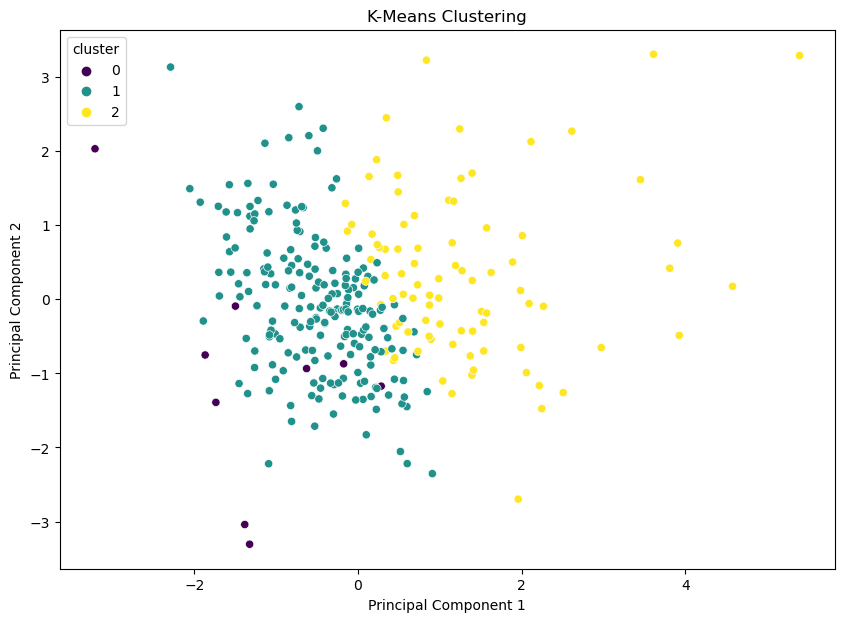

In [68]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=df_scaled['cluster'], palette='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

- Using visual inspection, we see that the data is reasonably well separated out into two distinct groups
- However, there is some overlap between the the purple and green clusters which indicates that the clusters are not well defined for the third group

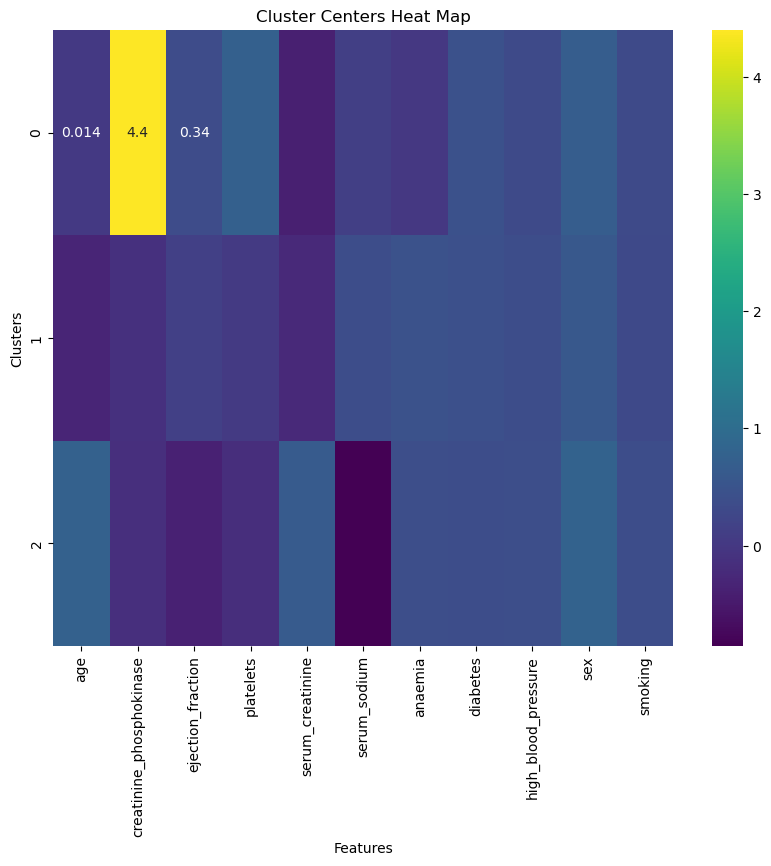

In [69]:
# Calculate the mean of each feature for each cluster
cluster_centers_original = df_scaled.groupby('cluster').mean()

# Create a heat map
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cluster_centers_original, annot=True, cmap='viridis')
plt.title('Cluster Centers Heat Map')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.show()

-  The above heatmap shows the variation in (scaled) values across clusters for each feature.
-  This shows that there is material variation in some features across clusters, with creatine_phosphokinase being the most obvious example indicating that it is a key driver in cluster formation
-  This is consistent with our observations in part 1 when we performed pair plots  
-  For some other features the variation is less obvious across clusters e.g., high blood pressure, diabetes, smoking

**(2) Hierarchical Clustering**

https://www.w3schools.com/python/python_ml_hierarchial_clustering.asp

In [65]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

In [66]:
# Perform hierarchical clustering
linked = linkage(df_scaled, method='ward')

Create a dendrogram which can then be visually inspected to see what the optimal number of clusters may be

Following link used to help create the dendrogram:

https://plotly.com/python/dendrogram/

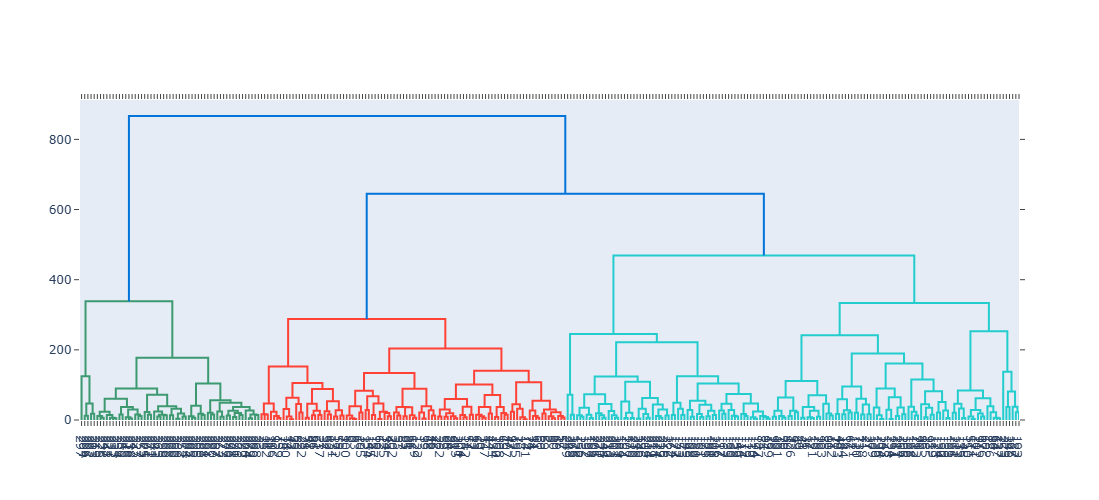

In [70]:
import plotly.figure_factory as ff
import numpy as np
np.random.seed(1)

X = np.random.rand(15, 12) # 15 samples, with 12 dimensions each
fig = ff.create_dendrogram(linked)
fig.update_layout(width=800, height=500)
fig.show()

From the above, we see that there appears to be at least 3 distinct clusters. It could also be argued that there are 4 distinct clusters.

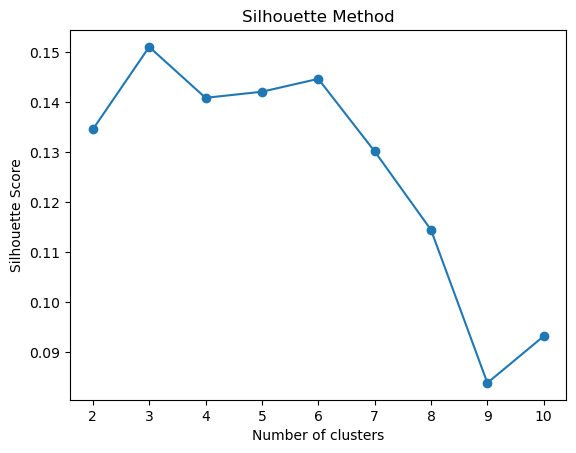

In [239]:
# Using the Silhouttte method
silhouette_scores = []
for k in range(2, 11):
    cluster_labels = fcluster(linked, k, criterion='maxclust') # Forms a tree with maximum number of clusters k
    score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

Based on the above, the optimal number of clusters is 3

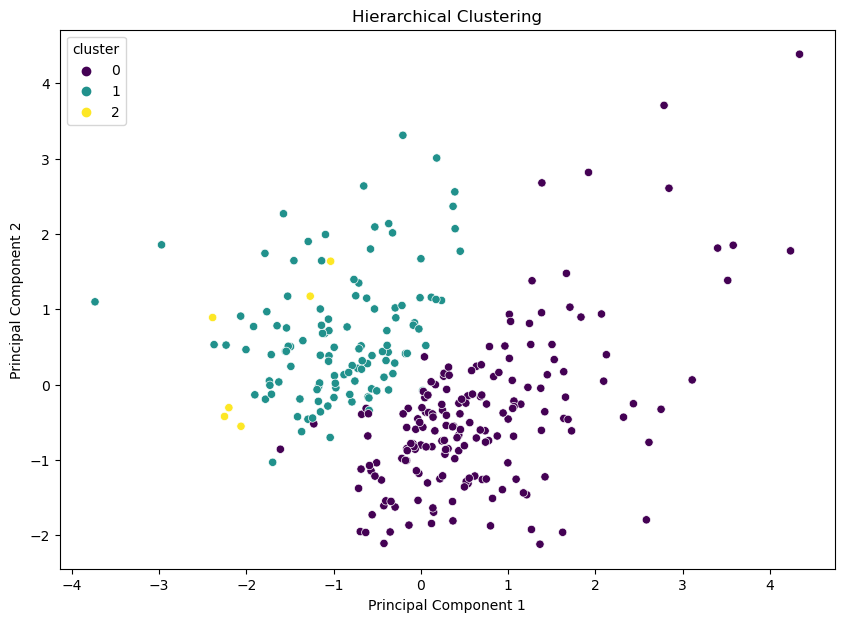

In [242]:
# Apply Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters= 3, affinity='euclidean', linkage='ward')
df_scaled['cluster'] = cluster.fit_predict(df_scaled)

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=df_scaled['cluster'], palette='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

- Using visual inspection, we see that the data is reasonably well separated out into two distinct groups
- However, there is significant overlap between the the yellow and green clusters which indicates that the clusters are not as well defined for the third group

### 4. Cluster Evaluation (2 Marks)

- Evaluate the clusters using appropriate evaluation metrics (e.g., silhouette score).
- 
Provide a comparative analysis of the clusters generated by both algorithms. Are the clusters similar or significantly different? What do the clusters suggest about the underlying data structure, especially regarding cardiac health risks?

### 5. Interpretation and Usefulness (1 Mark)

- Reflect on the interpretability of the clusters. Can the clusters provide meaningful insights into cardiac health risks?
- Discuss how clustering could be used in real-world applications, particularly in healthcare, to identify high-risk patients and tailor intervention strategies.